## Week 2 · Training an object detector  🧠

Now that we have a labelled (and augmented) dataset, we can **train** a neural network to find our objects in an image. We use [PyTorch](https://pytorch.org/) together with `torchvision`, which provides ready-made **object-detection** models (Faster R-CNN, RetinaNet, SSD…).

An object detector receives an image and predicts, for every object it finds, a bounding box and a label with a confidence score. Instead of learning this from zero, we start from weights **pre-trained on the COCO dataset** and only train the final layer for our own classes. This is called *transfer learning* and needs far less data.

We show the network the images in small groups (batches); it predicts boxes and a loss measures how wrong those predictions are. The optimizer nudges the weights to reduce that loss, and we repeat this for several passes over the whole dataset (epochs). After each epoch we measure the loss on a separate **validation** set (sequences the model never trains on) to check that it is really learning and not just memorising the training frames.

**Two things to keep in mind.**
- **Reproducibility.** Training is full of random choices (weight initialisation, data shuffling…). We fix a `SEED` so that every run produces the exact same result.
- **Resuming.** Training can take a long time, so we save the model after every epoch (`model_last.pt`). If it gets interrupted (the computer is turned off, the kernel dies…), just run the notebook again and it continues from the last completed epoch instead of starting over.

### Imports

In [1]:
import os
import random
import numpy as np
import xml.etree.ElementTree as ET
from typing import Tuple, Union, Any

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import detection
import torchvision.transforms.v2 as transforms

from torchvision.io import read_image, ImageReadMode
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

### Utils functions
Helper functions used throughout the notebook. Read the short docstrings to understand what each one does.

In [2]:
def new_history() -> dict:
    """Empty training history: losses per epoch, best validation loss and last finished epoch."""
    return {'train_loss': [], 'valid_loss': [], 'lr': [], 'best_value': np.inf, 'current_epoch': 0}


def set_seed(seed: int) -> None:
    """Fix every random source (Python, NumPy, PyTorch) so that runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def torch_load_cpu(path: str) -> Any:
    """Load a checkpoint onto the CPU."""
    return torch.load(path, map_location='cpu')


def load_checkpoint(path: str, model: Any, device: torch.device, optimizer: torch.optim = None) -> Tuple[Any, Any, dict]:
    """Load model weights, optimizer and RNG state from a checkpoint (to resume training or to test)."""
    checkpoint = torch_load_cpu(path)

    # Model weights
    model.load_state_dict({**model.state_dict(), **checkpoint.get('model', {})})

    # Random-number-generator state
    if 'rng_state' in checkpoint:
        torch.set_rng_state(checkpoint['rng_state'])
    if torch.cuda.is_available() and checkpoint.get('cuda_rng_state') is not None:
        torch.cuda.set_rng_state(checkpoint['cuda_rng_state'])
    if 'numpy_rng_state' in checkpoint:
        np.random.set_state(checkpoint['numpy_rng_state'])
    if 'python_rng_state' in checkpoint:
        random.setstate(checkpoint['python_rng_state'])

    # Optimizer state
    if optimizer is not None and 'optimizer' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer'])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)

    history = checkpoint.get('history', new_history())
    return model, optimizer, history


def save_checkpoint(path: str, model: Any, optimizer: torch.optim, lr_scheduler: Any, history: dict) -> None:
    """Save everything needed to resume training later (and to test the model afterwards)."""
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'lr_scheduler': lr_scheduler.state_dict(),
        'history': history,
        'rng_state': torch.get_rng_state(),
        'cuda_rng_state': torch.cuda.get_rng_state() if torch.cuda.is_available() else None,
        'numpy_rng_state': np.random.get_state(),
        'python_rng_state': random.getstate(),
    }, path)


def torchvision_model(model_name: str, pretrained: bool = False, num_classes: int = 2) -> Any:
    """Build a torchvision detection model and adapt its head to `num_classes` (0=background, 1=object)."""
    model_dict = {
        'faster_rcnn_v1': detection.fasterrcnn_resnet50_fpn,
        'faster_rcnn_v2': detection.fasterrcnn_resnet50_fpn_v2,
        'faster_rcnn_v3': detection.fasterrcnn_mobilenet_v3_large_fpn,
        'retinanet_v1': detection.retinanet_resnet50_fpn,
        'retinanet_v2': detection.retinanet_resnet50_fpn_v2,
        'ssd_v1': detection.ssd300_vgg16,
        'ssd_v2': detection.ssdlite320_mobilenet_v3_large,
    }
    assert model_name in model_dict, f"Unknown model '{model_name}'. Choose one of: {list(model_dict)}"

    # Load the architecture (optionally with COCO pre-trained weights)
    model = model_dict[model_name](weights='COCO_V1' if pretrained else None)

    # Replace the classification head so it predicts our number of classes
    if 'faster_rcnn' in model_name:
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    elif 'retinanet' in model_name:
        in_features = model.head.classification_head.cls_logits.in_channels
        num_anchors = model.head.classification_head.num_anchors
        model.head.classification_head = detection.retinanet.RetinaNetClassificationHead(in_features, num_anchors, num_classes)
    elif model_name == 'ssd_v1':
        in_features = [module.in_channels for module in model.head.classification_head.module_list]
        num_anchors = model.anchor_generator.num_anchors_per_location()
        model.head.classification_head = detection.ssd.SSDClassificationHead(in_features, num_anchors, num_classes)
    elif model_name == 'ssd_v2':
        in_features = [module[0][0].in_channels for module in model.head.classification_head.module_list]
        num_anchors = model.anchor_generator.num_anchors_per_location()
        model.head.classification_head = detection.ssd.SSDClassificationHead(in_features, num_anchors, num_classes)
    return model


def get_model(model_name: str, model_path: str = '', num_classes: int = 2, lr_data: list = None,
              pretrained: bool = False, use_gpu: bool = False) -> Tuple[Any, Any, dict, torch.device]:
    """Create the model (and optimizer) and, if a checkpoint exists at `model_path`, resume from it."""
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model = torchvision_model(model_name, pretrained, num_classes).to(device)

    # Optimizer
    if lr_data:
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.SGD(params, lr=lr_data[0], momentum=lr_data[1], weight_decay=lr_data[2])
    else:
        optimizer = None

    # Resume from a checkpoint if one is found
    if os.path.isfile(model_path):
        model, optimizer, history = load_checkpoint(model_path, model, device, optimizer)
        print(f"Resumed from '{model_path}' (epoch {history['current_epoch']}).")
    else:
        history = new_history()
        print(f"No checkpoint at '{model_path}'. Starting from scratch.")
    return model, optimizer, history, device


def clip_grad_norms(param_groups, max_norm: float = 0) -> None:
    """Clip gradient norms to avoid exploding gradients (max_norm=0 disables clipping)."""
    if max_norm <= 0:
        return
    for group in param_groups:
        torch.nn.utils.clip_grad_norm_(group['params'], max_norm, norm_type=2)

### Data Generator
A *Dataset* loads one image with its annotations at a time; a *DataLoader* groups several of them into a batch to feed the network during train, validation and test.

In [3]:
class CustomDataset(Dataset):
    """Feeds images and their bounding-box annotations to the network."""

    def __init__(self, path_dataset: str, resize_shape: tuple = None, transform: transforms.Compose = None) -> None:
        print("Loading annotations...")
        self.annotations = parse_annotations(path_dataset)
        self.resize_shape = resize_shape
        self.transform = transform

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, dict]:
        annotation = self.annotations[idx]

        # Load the image and its boxes/labels
        image = read_image(annotation['path_image'], ImageReadMode.RGB)
        boxes = torch.as_tensor(annotation['boxes'], dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(annotation['labels'], dtype=torch.int64)

        # Pre-process the image
        if self.transform:
            height, width = image.shape[-2:]
            image = self.transform(image)
            if self.resize_shape:
                boxes = resize_boxes(boxes, self.resize_shape, (height, width))

        # Torchvision detection models expect this structure
        return image, {'boxes': boxes, 'labels': labels}

    def __len__(self) -> int:
        return len(self.annotations)


def resize_boxes(boxes: torch.Tensor, resize_shape: tuple, image_shape: tuple) -> torch.Tensor:
    """Rescale [x_min, y_min, x_max, y_max] boxes when the image is resized (height, width)."""
    scale_h, scale_w = resize_shape[0] / image_shape[0], resize_shape[1] / image_shape[1]
    boxes[:, [0, 2]] *= scale_w
    boxes[:, [1, 3]] *= scale_h
    return boxes


def get_transform(resize_shape: Union[tuple, None] = None) -> transforms.Compose:
    """Turn an image into a float tensor in [0, 1]. Detection models normalise internally, so we do not normalise here."""
    t = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)]
    if resize_shape:
        t.append(transforms.Resize(resize_shape, antialias=True))
    return transforms.Compose(t)


def parse_annotations(path_dataset: str) -> list:
    """Read the dataset folder and return, per frame, the image path, its boxes and its labels."""
    annotations = []
    for sequence in tqdm(sorted(os.listdir(path_dataset))):
        labels_dir = os.path.join(path_dataset, sequence, 'labels')

        # Skip anything without a 'labels' folder
        if sequence.startswith('.') or not os.path.isdir(labels_dir):
            continue

        for frame in sorted(os.listdir(labels_dir)):
            label_path = os.path.join(labels_dir, frame)
            if not os.path.isfile(label_path):
                continue
            image_name, boxes = read_label(label_path)
            annotations.append({
                'path_image': os.path.join(path_dataset, sequence, 'images', image_name),
                'boxes': np.array(boxes, dtype=np.float32).reshape(-1, 4),
                'labels': np.array([1] * len(boxes), dtype=np.int64),  # 1 = object
            })
    return annotations


def read_label(xml_file: str) -> Tuple[str, list]:
    """Read a Pascal VOC XML file and return the image filename and its list of boxes."""
    root = ET.parse(xml_file).getroot()
    image_name = root.find('filename').text
    boxes = []
    for obj in root.iter('object'):
        box = obj.find('bndbox')
        xmin, ymin = int(box.find('xmin').text), int(box.find('ymin').text)
        xmax, ymax = int(box.find('xmax').text), int(box.find('ymax').text)
        boxes.append([xmin, ymin, xmax, ymax])
    return image_name, boxes


def collate_fn(batch: list) -> tuple:
    """Keep images and targets as tuples (they cannot be stacked: sizes and box counts differ)."""
    return tuple(zip(*batch))

### Parameters
Read each parameter, understand what it does, and play with them to get the best model.

In [4]:
# Seed for reproducibility (do NOT change it if you want identical results)
SEED = 0
set_seed(SEED)

In [5]:
# Data
local_path = '..'
path_data_train = f'{local_path}/data_train'           # Sequences used for training
path_data_val = f'{local_path}/data_val'               # Sequences used for validation

# Model
model_name = 'faster_rcnn_v1'                          # Torchvision model (see torchvision_model for the full list)
num_classes = 2                                        # ALWAYS 2: 0 is background, 1 is object
resize_shape = None                                    # (height, width) to resize images, or None to keep the original size
pretrained = True                                      # Start from COCO pre-trained weights (recommended)

# Training
num_epochs = 30                                        # Number of passes over the dataset
batch_size = 8                                         # Images per batch
num_workers = 0                                        # CPU processes loading data (0 means main process, fully reproducible)
use_gpu = True                                         # Use the GPU if available

# Optimizer (SGD) and learning-rate scheduler
lr = 0.0001                                            # Learning rate
lr_momentum = 0.9                                      # Momentum
lr_decay = 0.0005                                      # Weight decay (L2 regularization)
lr_factor = 0.1                                        # Multiply the LR by this when the validation loss stalls
lr_patience = 5                                        # Epochs to wait before reducing the LR
lr_threshold = 1e-4                                    # Minimum improvement to count as "getting better"
lr_min = 1e-10                                         # Lower bound for the LR

In [7]:
# Path to save the model
model_dir = f'{local_path}/models/{model_name}'
model_best_path = f'{model_dir}/model_best.pt'         # Best model (lowest val loss)  -> used later for testing
model_last_path = f'{model_dir}/model_last.pt'         # Latest model after each epoch -> used to resume training

In [8]:
# Gradient clipping
max_grad_norm = 1 if model_name in ['ssd_v1'] else 0

### Train

In [9]:
# Load model and optimizer
model, optimizer, history, device = get_model(
    model_name=model_name,
    model_path=model_last_path,
    num_classes=num_classes,
    lr_data=[lr, lr_momentum, lr_decay],
    pretrained=pretrained,
    use_gpu=use_gpu,
)

# Learning-rate scheduler: reduce the LR when the validation loss plateaus
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=lr_factor, patience=lr_patience, threshold=lr_threshold, min_lr=lr_min,
)
if os.path.isfile(model_last_path):
    lr_scheduler.load_state_dict(torch_load_cpu(model_last_path)['lr_scheduler'])

No checkpoint at '../models/faster_rcnn_v1/model_last.pt'. Starting from scratch.


Create the output folder and the data pipeline. Build one Dataset for training and another one for validation. Notice the difference between a **Dataset** (loads one sample) and a **DataLoader** (groups samples into batches).

In [10]:
# Create the folder where the model will be saved
os.makedirs(model_dir, exist_ok=True)

# Image pre-processing
transform = get_transform(resize_shape)

# Datasets
train_set = CustomDataset(path_dataset=path_data_train, resize_shape=resize_shape, transform=transform)
valid_set = CustomDataset(path_dataset=path_data_val, resize_shape=resize_shape, transform=transform)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, collate_fn=collate_fn)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, collate_fn=collate_fn)

Loading annotations...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 731.28it/s]


Loading annotations...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 724.35it/s]


Now we train until convergence. Read the loop carefully: for each **epoch** we go over the training set to update the weights, then over the validation set to measure progress, and finally we **save a checkpoint** so the training can always be resumed.

In [11]:
for epoch in range(history['current_epoch'], num_epochs):

    # ----- Training: update the weights -----
    model.train()
    train_losses = []
    for images, targets in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [train]'):

        # Move data to the device
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

        # Predict and add up the losses the model returns
        loss = sum(model(images, targets).values())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norms(optimizer.param_groups, max_grad_norm)
        optimizer.step()
        train_losses.append(loss.item())

    # ----- Validation: measure the loss without updating the weights -----
    # NOTE: we keep the model in train() mode on purpose; in eval() mode it would
    # return detections instead of the losses. torch.no_grad() disables gradients.
    valid_losses = []
    with torch.no_grad():
        for images, targets in tqdm(valid_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [valid]'):
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
            valid_losses.append(sum(model(images, targets).values()).item())

    # ----- Save results -----
    train_loss, valid_loss = float(np.mean(train_losses)), float(np.mean(valid_losses))
    history['current_epoch'] = epoch + 1
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])   # learning rate used during this epoch
    lr_scheduler.step(valid_loss)                           # may lower the LR for the next epoch
    print(f" -> train loss: {train_loss:.4f} | valid loss: {valid_loss:.4f}\n")

    # Save best and last models
    save_checkpoint(model_last_path, model, optimizer, lr_scheduler, history)
    if valid_loss < history['best_value']:
        history['best_value'] = valid_loss
        save_checkpoint(model_best_path, model, optimizer, lr_scheduler, history)

Epoch 1/30 [valid]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [00:14<00:00,  5.81it/s]


 -> train loss: 0.6659 | valid loss: 0.5339



Epoch 2/30 [valid]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [00:14<00:00,  5.81it/s]


 -> train loss: 0.5420 | valid loss: 0.4659



Epoch 3/30 [valid]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [00:14<00:00,  5.82it/s]


...

 -> train loss: 0.1106 | valid loss: 0.2103



Epoch 29/30 [valid]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [00:14<00:00,  5.81it/s]


 -> train loss: 0.1090 | valid loss: 0.2091



Epoch 30/30 [valid]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [00:14<00:00,  5.82it/s]


 -> train loss: 0.1079 | valid loss: 0.2121



### Plots

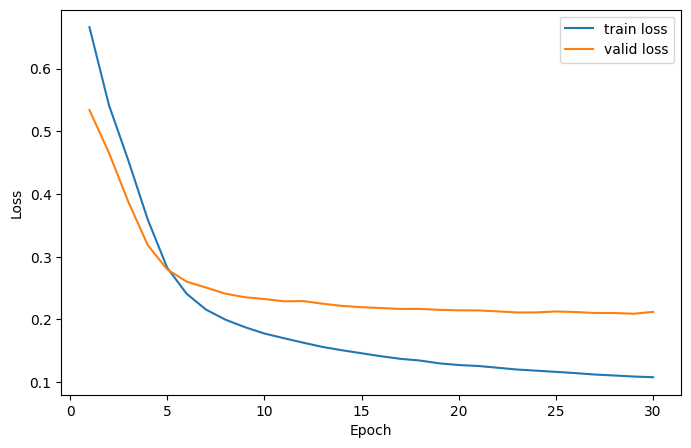

In [12]:
# Plot results
epochs = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], label='train loss')
plt.plot(epochs, history['valid_loss'], label='valid loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(model_dir, 'history.png'))
plt.show()

The scheduler lowers the learning rate whenever the validation loss stops improving. Let's see how it evolved.

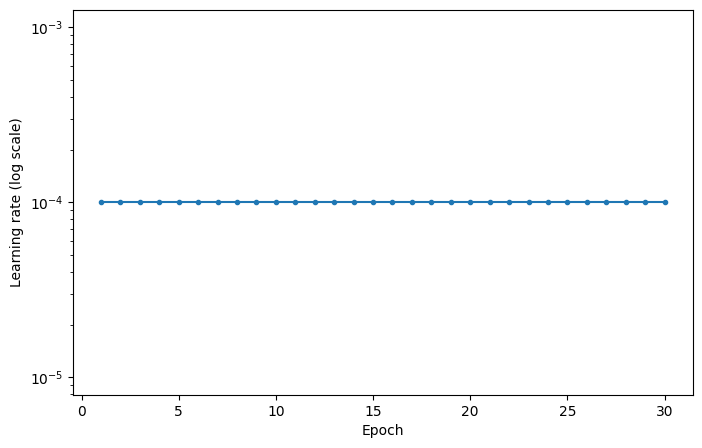

In [13]:
# Plot the learning-rate evolution
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history['lr']) + 1), history['lr'], marker='.')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Learning rate (log scale)')
plt.savefig(os.path.join(model_dir, 'lr.png'))
plt.show()